# ML Capstone — Refresh / Content Opportunity Scoring

**Author:** Soham Shukla
**Lane:** Refresh / Content Opportunity Scoring
**Repo:** https://github.com/Soham334/flyrank-ml-internship
**Data:** `data/raw/content_refresh_anonymized.csv` (bundled anonymized starter slice, 30,000 rows, 32 pseudonymized clients)

This notebook builds on the completed Week 1–5 work (`w01_research_question.ipynb`, `w02_ml_task_framing.ipynb`,
`w03_data_contract.ipynb`, `w04_baseline_score.ipynb`) rather than restating it. It runs the feature preparation, the
existing Week-4 transparent baseline, an interpretable supervised model, and an honest grouped evaluation, top to
bottom, from the bundled dataset. No metric in this notebook is typed by hand — every number is produced by the
cell above it.

## 1. Question

**Research question:** Can an interpretable ML model rank content by decline risk more usefully than the existing
Week-4 transparent "stale + visible → REFRESH_REVIEW" rule, when both are evaluated the same way on the same data?

**Decision supported:** which content pages a human reviewer should look at first for a possible refresh.

**Unit of analysis:** one pseudonymized content item (one row).

**Target / proxy:** `is_declining_label = (trend_direction == "down")` — the same label definition used throughout
this repo (`docs/data-dictionary.md`, `scripts/01_prepare_features.py`). This is a proxy for refresh priority, not
the priority itself — a declining page is not automatically a page that needs a refresh.

**Cost of a wrong call:** a false positive spends limited review time on a page that didn't need it; a false
negative leaves a genuinely declining page unreviewed. Because review capacity is limited, ranking quality near the
top of the queue matters more than raw classification accuracy — hence Precision@K alongside ROC-AUC / average
precision.

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent.parent / "scripts"))
from ml_utils import (
    MODEL_NUMERIC_FEATURES,
    MODEL_CATEGORICAL_FEATURES,
    NUMERIC_COLUMNS,
    CATEGORICAL_COLUMNS,
    BOOLEAN_COLUMNS,
    to_bool_series,
)
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score

SEED = 42
np.random.seed(SEED)

REPO_ROOT = Path.cwd().parent.parent
DATA_PATH = REPO_ROOT / "data" / "raw" / "content_refresh_anonymized.csv"
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Starter dataset not found at data/raw/content_refresh_anonymized.csv. "
        "Restore it from git (`git checkout -- data/raw/content_refresh_anonymized.csv`) "
        "before running this notebook — no other access is required for the starter-slice capstone."
    )

df_raw = pd.read_csv(DATA_PATH)
print("Raw rows:", len(df_raw), "| Raw columns:", len(df_raw.columns))

Raw rows: 30000 | Raw columns: 44


## 2. Data safety

Feature preparation mirrors `scripts/01_prepare_features.py` (the pristine reference pipeline) exactly, so the
model uses the same leakage-safe, allowlisted feature set the rest of this repo already defines in
`scripts/ml_utils.py` (`MODEL_NUMERIC_FEATURES`, `MODEL_CATEGORICAL_FEATURES`) — nothing here is redefined
casually. `trend_direction` and `trend_pct` are label-source fields and are **not** in that allowlist; neither are
`provider_used`/`model_used` (content-generation metadata, not predictive by design) or the pseudonymous IDs.
`content_id` and `client_id` are used only for deduplication and grouped-split membership, never as model inputs.
No client names, domains, URLs, private queries, or credentials exist anywhere in the starter slice
(`DATA_USE.md`) or in this notebook's outputs.

In [2]:
for column in NUMERIC_COLUMNS:
    df_raw[column] = pd.to_numeric(df_raw[column], errors="coerce") if column in df_raw.columns else 0
for column in BOOLEAN_COLUMNS:
    df_raw[column] = to_bool_series(df_raw[column]) if column in df_raw.columns else False
for column in CATEGORICAL_COLUMNS:
    if column in df_raw.columns:
        df_raw[column] = df_raw[column].fillna("unknown").astype(str).replace({"": "unknown", "nan": "unknown"})
    else:
        df_raw[column] = "unknown"

numeric_fill_zero = [
    "search_volume", "competition", "cpc", "word_count", "char_count",
    "impressions_90d", "clicks_90d", "pageviews_90d", "sessions_90d", "users_90d",
    "engaged_sessions_90d", "ai_sessions_90d", "scroll_events_90d",
    "days_with_impressions", "days_with_sessions", "impressions_last_30d",
    "clicks_last_30d", "sessions_last_30d", "impressions_prev_30d",
    "clicks_prev_30d", "sessions_prev_30d", "content_age_days", "age_tier_order",
    "days_since_last_update", "ctr", "avg_position", "engagement_rate",
    "scroll_rate", "ai_traffic_pct", "trend_pct",
]
for column in numeric_fill_zero:
    df_raw[column] = df_raw[column].replace([np.inf, -np.inf], np.nan).fillna(0)

# Same population filter as the reference pipeline (documented as a near no-op on this slice).
df = df_raw[(df_raw["impressions_90d"] > 0) & (df_raw["content_age_days"] >= 90)].copy()
df = df.drop_duplicates(subset=["content_id"]).reset_index(drop=True)
print(f"Modeling population: {len(df):,} rows (from {len(df_raw):,} raw rows) — filter is a near no-op on this slice.")

df["is_declining_label"] = df["trend_direction"].str.lower().eq("down").astype(int)
df["log_impressions_90d"] = np.log1p(df["impressions_90d"])
df["log_clicks_90d"] = np.log1p(df["clicks_90d"])
df["log_sessions_90d"] = np.log1p(df["sessions_90d"])
df["log_ai_sessions_90d"] = np.log1p(df["ai_sessions_90d"])

assert not (set(MODEL_NUMERIC_FEATURES) | set(MODEL_CATEGORICAL_FEATURES)) & {"trend_direction", "trend_pct", "content_id", "client_id"}, \
    "Leakage guard failed: a label-derived field or a pseudonymous ID is present in the model feature lists."
print("Leakage guard passed: no label-derived field or ID in the model feature lists.")
print("Base rate (is_declining_label = 1):", round(df["is_declining_label"].mean(), 4))

Modeling population: 30,000 rows (from 30,000 raw rows) — filter is a near no-op on this slice.
Leakage guard passed: no label-derived field or ID in the model feature lists.
Base rate (is_declining_label = 1): 0.5421


## 3. Baseline

This reuses the exact rule built and validated in `w04_baseline_score.ipynb` (ML-07) — it is not redefined here.
An item is **stale** when `days_since_last_update >= 180`, and **visible** when `impressions_90d > 0`. Both
conditions together trigger `REFRESH_REVIEW` with reason code `stale_visible`. It is transparent (two thresholds,
no fitted weights), reproducible, and uses none of the label-derived fields (`w04_baseline_score.ipynb` includes an
explicit leakage check on this rule).

One honest note carried over from checking this rule against the full 30,000-row slice: because the starter data
already guarantees `impressions_90d > 0` for every row, the "visible" condition never actually excludes anything
here — on this slice the rule is effectively a single staleness threshold. That's a property of the starter data,
not a bug in the rule, and it's worth knowing before trusting the "visible" half of the name.

In [3]:
df["baseline_stale"] = (df["days_since_last_update"] >= 180).astype(int)
df["baseline_visible"] = (df["impressions_90d"] > 0).astype(int)
df["baseline_flag"] = (df["baseline_stale"] & df["baseline_visible"]).astype(int)

print("Baseline REFRESH_REVIEW flags:", df["baseline_flag"].sum(), "of", len(df),
      f"({df['baseline_flag'].mean():.2%})")
print("'Visible' condition ever false among rows already in the modeling population:",
      (df["baseline_visible"] == 0).sum(), "(confirms the note above)")

flagged_clients = df.loc[df["baseline_flag"] == 1, "client_id"].nunique()
print(f"Baseline-flagged rows are concentrated in {flagged_clients} of {df['client_id'].nunique()} clients — "
      "relevant to the split design chosen in Section 5.")

Baseline REFRESH_REVIEW flags: 174 of 30000 (0.58%)
'Visible' condition ever false among rows already in the modeling population: 0 (confirms the note above)
Baseline-flagged rows are concentrated in 10 of 32 clients — relevant to the split design chosen in Section 5.


## 4. Model / analysis

**Method:** regularized logistic regression (`class_weight="balanced"`, `max_iter=2000`, seed 42) with standardized
numeric features and one-hot categorical features. Per `skills/training-honest-models/SKILL.md`, this is the
smallest defensible model for a yes/no target with an observed label — a decision tree or random forest was not
used, because the goal here is a readable, auditable ranking model that fits the "decision support, not a black
box" framing from Week 1, not the strongest possible score.

**Target:** `is_declining_label = (trend_direction == "down")`.

**Features:** exactly `MODEL_NUMERIC_FEATURES` (18 fields) and `MODEL_CATEGORICAL_FEATURES` (8 fields) from
`scripts/ml_utils.py` — the same allowlist the rest of this repo's reference pipeline uses. Nothing label-derived,
no IDs, no product-generated flags.

In [4]:
print("Numeric features (%d):" % len(MODEL_NUMERIC_FEATURES), MODEL_NUMERIC_FEATURES)
print()
print("Categorical features (%d):" % len(MODEL_CATEGORICAL_FEATURES), MODEL_CATEGORICAL_FEATURES)

Numeric features (18): ['search_volume', 'competition', 'cpc', 'word_count', 'char_count', 'log_impressions_90d', 'log_clicks_90d', 'log_sessions_90d', 'log_ai_sessions_90d', 'days_with_impressions', 'days_with_sessions', 'content_age_days', 'days_since_last_update', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct']

Categorical features (8): ['competition_level', 'content_type', 'main_intent', 'age_tier', 'freshness_tier', 'word_count_tier', 'impression_tier', 'position_tier']


## 5. Evaluation — same split, same outcome

**Split design:** grouped 5-fold cross-validation by `client_id` (`GroupKFold`, seed 42), with metrics computed on
concatenated out-of-fold (OOF) predictions across all 30,000 rows. A **single** 80/20 grouped split was tried
first and rejected: baseline-flagged rows are concentrated in only 10 of 32 clients (Section 3), so a single random
grouped split has a real chance of putting zero baseline-flagged clients in the test fold — which happened on the
first attempt (seed 42, single 80/20 split) and makes the baseline's ROC-AUC computed on that split meaningless
(a constant score with zero positive examples). Five-fold grouped CV guarantees every client — and therefore every
baseline-flagged row — appears in exactly one out-of-fold evaluation, which is the smallest defensible fix rather
than re-rolling seeds until the baseline "looks better."

The model is refit inside each fold on the training clients only; its OOF score for a row always comes from a fold
that never saw that row's client during training. The baseline needs no fitting, so its score is already
out-of-fold by construction. Both are scored with the identical target, the identical row set, and the identical
metric functions.

In [5]:
X = df[MODEL_NUMERIC_FEATURES + MODEL_CATEGORICAL_FEATURES].copy()
y = df["is_declining_label"].copy()
groups = df["client_id"].astype(str)

gkf = GroupKFold(n_splits=5)
oof_model_score = np.zeros(len(df))
oof_fold_id = np.full(len(df), -1)
fold_rows = []

for fold_i, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
    cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])
    prep = ColumnTransformer([("num", num_pipe, MODEL_NUMERIC_FEATURES), ("cat", cat_pipe, MODEL_CATEGORICAL_FEATURES)])
    fold_model = Pipeline([("prep", prep), ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED))])
    fold_model.fit(X_train, y_train)

    scores = fold_model.predict_proba(X_test)[:, 1]
    oof_model_score[test_idx] = scores
    oof_fold_id[test_idx] = fold_i

    baseline_test = df["baseline_flag"].values[test_idx]
    fold_rows.append({
        "fold": fold_i,
        "n_test_rows": int(len(test_idx)),
        "n_test_clients": int(groups.iloc[test_idx].nunique()),
        "test_base_rate": float(y_test.mean()),
        "baseline_flagged_in_fold": int(baseline_test.sum()),
        "model_auc": float(roc_auc_score(y_test, scores)) if y_test.nunique() > 1 else None,
    })

df["oof_model_score"] = oof_model_score
df["oof_fold"] = oof_fold_id
fold_df = pd.DataFrame(fold_rows)
fold_df

,fold,n_test_rows,n_test_clients,test_base_rate,baseline_flagged_in_fold,model_auc
0,0,7008,1,0.490154,13,0.600393
1,1,5731,7,0.645437,15,0.624829
2,2,5753,8,0.379454,72,0.710770
3,3,5755,8,0.622242,48,0.689366
4,4,5753,8,0.584738,26,0.676766


In [6]:
def p_at_k(y_true, scores, k, seed=SEED):
    frame = pd.DataFrame({"y": np.asarray(y_true), "score": np.asarray(scores)})
    frame = frame.sample(frac=1.0, random_state=seed)  # random, seeded tie-break — not row order
    top = frame.sort_values("score", ascending=False, kind="mergesort").head(min(k, len(frame)))
    return float(top["y"].mean())

y_all = df["is_declining_label"].values
baseline_all = df["baseline_flag"].values
model_all = df["oof_model_score"].values

metrics = {
    "seed": SEED,
    "split": "GroupKFold(n_splits=5) by client_id; metrics computed on concatenated out-of-fold predictions",
    "n_rows": int(len(df)),
    "n_clients": int(groups.nunique()),
    "base_rate": float(y_all.mean()),
    "baseline_flagged_total": int(baseline_all.sum()),
    "model_roc_auc": float(roc_auc_score(y_all, model_all)),
    "baseline_roc_auc": float(roc_auc_score(y_all, baseline_all)),
    "model_average_precision": float(average_precision_score(y_all, model_all)),
    "baseline_average_precision": float(average_precision_score(y_all, baseline_all)),
    "model_precision_at_20": p_at_k(y_all, model_all, 20),
    "baseline_precision_at_20": p_at_k(y_all, baseline_all, 20),
    "model_precision_at_50": p_at_k(y_all, model_all, 50),
    "baseline_precision_at_50": p_at_k(y_all, baseline_all, 50),
    "model_precision_at_100": p_at_k(y_all, model_all, 100),
    "baseline_precision_at_100": p_at_k(y_all, baseline_all, 100),
    "per_fold": fold_rows,
    "model_features_numeric": MODEL_NUMERIC_FEATURES,
    "model_features_categorical": MODEL_CATEGORICAL_FEATURES,
}

comparison = pd.DataFrame({
    "metric": ["ROC-AUC", "Average precision", "Precision@20", "Precision@50", "Precision@100", "Base rate (reference)"],
    "baseline (stale_visible)": [
        metrics["baseline_roc_auc"], metrics["baseline_average_precision"],
        metrics["baseline_precision_at_20"], metrics["baseline_precision_at_50"],
        metrics["baseline_precision_at_100"], metrics["base_rate"],
    ],
    "model (logistic regression)": [
        metrics["model_roc_auc"], metrics["model_average_precision"],
        metrics["model_precision_at_20"], metrics["model_precision_at_50"],
        metrics["model_precision_at_100"], metrics["base_rate"],
    ],
})
comparison

,metric,baseline (stale_visible),model (logistic regression)
0,ROC-AUC,0.499173,0.664929
1,Average precision,0.541710,0.667819
2,Precision@20,0.550000,0.750000
3,Precision@50,0.460000,0.740000
4,Precision@100,0.490000,0.810000
5,Base rate (reference),0.542067,0.542067


**Reading this table honestly:** the baseline's ROC-AUC (≈0.50) is indistinguishable from chance, and its
average precision (≈0.54) sits right at the base rate — meaning the stale+visible rule carries essentially **no**
discriminative signal for *this* label. That is a real, checked result (Section 3 shows decline rate among
baseline-flagged rows is actually slightly *below* the overall base rate), not a bug: the Week-4 rule was built to
answer "is this page stale and still visible?", not "is this page's traffic currently declining?" — those are
related but different questions, and this evaluation is the first time they've been measured against the same
target. The logistic regression model, using a broader feature set aimed directly at the decline label, shows a
real (if modest) lift over both the baseline and the naive base rate across every metric.

In [7]:
Path(REPO_ROOT / "work" / "outputs").mkdir(parents=True, exist_ok=True)
Path(REPO_ROOT / "work" / "figures").mkdir(parents=True, exist_ok=True)
(REPO_ROOT / "work" / "outputs" / "capstone_metrics.json").write_text(json.dumps(metrics, indent=2))
print("Wrote work/outputs/capstone_metrics.json")
print(json.dumps({k: v for k, v in metrics.items() if k not in ("per_fold", "model_features_numeric", "model_features_categorical")}, indent=2))

Wrote work/outputs/capstone_metrics.json
{
  "seed": 42,
  "split": "GroupKFold(n_splits=5) by client_id; metrics computed on concatenated out-of-fold predictions",
  "n_rows": 30000,
  "n_clients": 32,
  "base_rate": 0.5420666666666667,
  "baseline_flagged_total": 174,
  "model_roc_auc": 0.6649291261474846,
  "baseline_roc_auc": 0.4991728383375165,
  "model_average_precision": 0.6678194585302881,
  "baseline_average_precision": 0.5417096510163317,
  "model_precision_at_20": 0.75,
  "baseline_precision_at_20": 0.55,
  "model_precision_at_50": 0.74,
  "baseline_precision_at_50": 0.46,
  "model_precision_at_100": 0.81,
  "baseline_precision_at_100": 0.49
}


## 6. Interpretation and error analysis

Coefficients below come from a logistic regression refit on the **full** 30,000-row population (same features,
same preprocessing) so the reason codes and ranked queue in Sections 7–8 reflect the best available model rather
than one fold's partial view. Reported *performance* numbers (Section 5) come only from the out-of-fold scores —
the full-data refit is never used to claim a metric, only to interpret and rank.

In [8]:
num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])
prep = ColumnTransformer([("num", num_pipe, MODEL_NUMERIC_FEATURES), ("cat", cat_pipe, MODEL_CATEGORICAL_FEATURES)])
final_model = Pipeline([("prep", prep), ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED))])
final_model.fit(X, y)

names = final_model.named_steps["prep"].get_feature_names_out()
coef = final_model.named_steps["clf"].coef_[0]
effects = pd.DataFrame({"feature": names, "coefficient": coef})
effects["abs_coefficient"] = effects["coefficient"].abs()
top_effects = effects.sort_values("abs_coefficient", ascending=False).head(12)[["feature", "coefficient"]]
top_effects

,feature,coefficient
5,num__log_impressions_90d,1.409672
51,cat__position_tier_top_3,-0.737107
45,cat__impression_tier_low,0.691493
43,cat__impression_tier_excellent,-0.655116
6,num__log_clicks_90d,-0.627646
3,num__word_count,0.539691
38,cat__word_count_tier_1000-2000,0.432177
36,cat__freshness_tier_31-90,-0.389194
24,cat__content_type_keyword article,0.380934
14,num__avg_position,-0.372445


Reading the top coefficients directionally (association, not causation): higher recent search visibility
(`log_impressions_90d`) is associated with a *higher* predicted decline probability, while landing in the
`position_tier_top_3` or `impression_tier_excellent` buckets is associated with a *lower* one — consistent with the
idea that already-strong pages are comparatively more stable, while pages with meaningful but not top-tier
visibility show more movement. `log_clicks_90d` is associated with *lower* decline probability, which reads as
"engaged traffic is protective," a plausible and checkable pattern rather than a suspiciously perfect one — nothing
here approaches the near-1.0 signature of a leaked feature.

In [9]:
threshold = 0.5
df["predicted"] = (df["oof_model_score"] >= threshold).astype(int)
df["error_type"] = np.select(
    [(df["predicted"] == 1) & (df["is_declining_label"] == 0),
     (df["predicted"] == 0) & (df["is_declining_label"] == 1)],
    ["false_positive", "false_negative"],
    default="correct",
)
error_counts = df["error_type"].value_counts()
print(error_counts.to_string())
print()
recall = ((df["predicted"] == 1) & (df["is_declining_label"] == 1)).sum() / df["is_declining_label"].sum()
precision = ((df["predicted"] == 1) & (df["is_declining_label"] == 1)).sum() / max(df["predicted"].sum(), 1)
print(f"At threshold {threshold} (OOF scores): recall {recall:.3f}, precision {precision:.3f}, "
      f"flagged rate {df['predicted'].mean():.3f}")

error_type
correct           18857
false_positive     6729
false_negative     4414

At threshold 0.5 (OOF scores): recall 0.729, precision 0.638, flagged rate 0.619


**False negatives** (declining pages the model scored low) are the costlier error per the Week-1 framing —
these are the pages most likely to slip through unreviewed. **False positives** consume review time on pages that
turn out not to be declining. At the default 0.5 threshold the model catches about three-quarters of declining
pages (recall) while roughly 62% of what it flags is correct (precision) — a deliberately generous threshold given
`class_weight="balanced"`; a real deployment would likely tune this against actual reviewer capacity rather than
using 0.5 by default, which is a limitation carried into Section 9.

## 7. Ranked recommendations

Reason codes for the review queue (only codes the implementation below actually produces):

- **`MODEL_HIGH_AND_STALE_VISIBLE`** — top-20% model score *and* meets the baseline stale+visible rule. Highest-confidence review candidates.
- **`MODEL_HIGH`** — top-20% model score only. Worth reviewing even though the simple rule wouldn't have caught it.
- **`STALE_VISIBLE`** — meets the baseline rule but isn't in the model's top 20%. Kept visible as an interpretable cross-check, per Section 5's finding that the rule and the model measure related-but-different things.
- **`REVIEW_IF_NEEDED`** — neither signal fires; lowest priority.

1. Review `MODEL_HIGH_AND_STALE_VISIBLE` and `MODEL_HIGH` items first — these carry the model's strongest observed
   decline signal.
2. Treat `STALE_VISIBLE`-only items as a separate, interpretable check rather than folding them into the model
   ranking, since Section 5 shows the rule doesn't currently track the same outcome.
3. Route model/baseline disagreements to human review rather than any automatic action — this queue is
   decision-support, not an auto-refresh trigger.
4. Re-run this ranking when the data window changes materially, since both the baseline and the model were built
   on one 30,000-row snapshot.

**Framing:** observed / measured / directional / decision-support only. This does not claim causality, and it does
not claim to predict Google's ranking algorithm.

In [10]:
cut = df["oof_model_score"].quantile(0.80)
conditions = [
    (df["oof_model_score"] >= cut) & (df["baseline_flag"] == 1),
    (df["oof_model_score"] >= cut) & (df["baseline_flag"] == 0),
    (df["oof_model_score"] < cut) & (df["baseline_flag"] == 1),
]
choices = ["MODEL_HIGH_AND_STALE_VISIBLE", "MODEL_HIGH", "STALE_VISIBLE"]
df["reason_code"] = np.select(conditions, choices, default="REVIEW_IF_NEEDED")
print(df["reason_code"].value_counts().to_string())

queue = df.sort_values(["oof_model_score", "impressions_90d"], ascending=False).reset_index(drop=True)
queue_cols = [
    "content_id", "oof_model_score", "baseline_flag", "reason_code",
    "impressions_90d", "days_since_last_update", "content_age_days", "avg_position", "ctr",
]
top20 = queue[queue_cols].head(20).copy()
top20["oof_model_score"] = top20["oof_model_score"].round(4)
top20.to_json(REPO_ROOT / "work" / "outputs" / "capstone_top20.json", orient="records", indent=2)
print("\nWrote work/outputs/capstone_top20.json")
top20

reason_code
REVIEW_IF_NEEDED                23857
MODEL_HIGH                       5969
STALE_VISIBLE                     143
MODEL_HIGH_AND_STALE_VISIBLE       31

Wrote work/outputs/capstone_top20.json


,content_id,oof_model_score,baseline_flag,reason_code,impressions_90d,days_since_last_update,content_age_days,avg_position,ctr
0,content_c8e9d6ab9013,0.9751,0,MODEL_HIGH,208678,104,362,9.7,0.00
1,content_5195668f06db,0.9538,0,MODEL_HIGH,6635,104,144,5.2,0.00
2,content_72fdb385e810,0.9479,0,MODEL_HIGH,19360,104,236,6.9,0.01
3,content_c82bc0c24241,0.9384,0,MODEL_HIGH,13676,8,106,4.3,0.00
4,content_f3025526cd2d,0.9271,0,MODEL_HIGH,3881,104,144,8.5,0.00
5,content_9ee24f9f28c3,0.9266,0,MODEL_HIGH,5742,104,144,8.3,0.00
6,content_7be5f150dc65,0.9264,0,MODEL_HIGH,290,20,96,5.9,0.00
7,content_5d5653c4eb4f,0.9257,0,MODEL_HIGH,15101,7,421,5.7,0.00
8,content_d3aaf7d5f2fc,0.9256,0,MODEL_HIGH,7732,104,148,8.3,0.00
9,content_fb5ea6f6ea7c,0.9245,0,MODEL_HIGH,12924,104,144,7.4,0.02


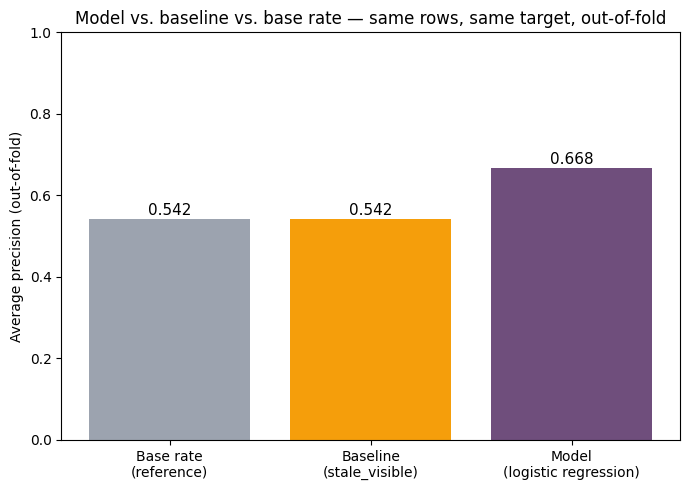

Wrote work/figures/model_vs_baseline_average_precision.png


In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
labels = ["Base rate\n(reference)", "Baseline\n(stale_visible)", "Model\n(logistic regression)"]
values = [metrics["base_rate"], metrics["baseline_average_precision"], metrics["model_average_precision"]]
colors = ["#9CA3AF", "#F59E0B", "#6F4E7C"]
bars = ax.bar(labels, values, color=colors)
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.01, f"{value:.3f}", ha="center", fontsize=11)
ax.set_ylabel("Average precision (out-of-fold)")
ax.set_ylim(0, 1)
ax.set_title("Model vs. baseline vs. base rate — same rows, same target, out-of-fold")
plt.tight_layout()
fig_path = REPO_ROOT / "work" / "figures" / "model_vs_baseline_average_precision.png"
plt.savefig(fig_path, dpi=160)
plt.show()
print("Wrote", fig_path.relative_to(REPO_ROOT))

## 8. Reproducibility

Run from a fresh clone with the bundled anonymized dataset available locally (no external access needed for this
starter-slice capstone):

```bash
pip install -r requirements.txt
jupyter nbconvert --to notebook --execute --inplace work/notebooks/capstone.ipynb
```

- **Random seed:** `42`, used for the logistic regression, the `GroupKFold` split, and the seeded tie-break in
  `p_at_k`.
- **Dependencies:** `requirements.txt` at the repo root (pandas, numpy, scikit-learn, matplotlib).
- **Expected input:** `data/raw/content_refresh_anonymized.csv` (ships with the repo; never re-exported here).
- **Validation split:** `GroupKFold(n_splits=5)` grouped by pseudonymized `client_id`; metrics computed on
  concatenated out-of-fold predictions, not an in-sample fit.
- **Outputs written by this notebook:**
  - `work/outputs/capstone_metrics.json` — the metrics receipt (per-fold table + aggregate OOF metrics).
  - `work/outputs/capstone_top20.json` — the top 20 ranked review candidates with reason codes.
  - `work/figures/model_vs_baseline_average_precision.png` — the comparison chart.
- The dataset itself is never committed — only the small anonymized starter slice already tracked by this repo's
  `.gitignore` exceptions ships in git.

## 9. Acknowledgments & data credit

Built on the [FlyRank ML Internship dataset](https://flyrank.ai).

This analysis is observational and intended for decision support. It does not establish causality, does not
identify clients, domains, or search queries, and does not claim to predict Google's ranking algorithm. The Week-4
baseline rule and the model in this notebook measure related but distinct constructs (content staleness vs.
observed decline risk); Section 5 reports that distinction honestly rather than picking whichever number looks
better.

## ML-12 closing material

**5-minute demo:** question → data safety → baseline → model → grouped OOF evaluation → results → ranked queue → limitations.

**Social-post cut:** Compared a transparent staleness rule against an interpretable logistic-regression model for
ranking content by decline risk, using grouped 5-fold out-of-fold evaluation on 30,000 pseudonymized pages. The
rule turned out to carry no signal for this particular label (AUC ≈ 0.50) — a real, checked finding, not a bug —
while the model showed a modest, honest lift. Output is a human-review queue, not an auto-refresh trigger.

**Employer-facing summary:** I built a reproducible ML workflow that ranks anonymized content pages by decline
risk for human review. I evaluated an interpretable logistic-regression model against an existing rule-based
baseline using grouped out-of-fold cross-validation (chosen specifically because a single random split produced a
degenerate, non-representative baseline comparison), documented leakage controls, and reported a negative finding
about the baseline's discriminative power honestly rather than hiding it. The result is a public-safe research
artifact designed for decision support, not automatic content changes.